# MCP (Model Context Protocol)

## MCP란

MCP는 AI Agent가 외부 Tool을 사용하는 방식을 **표준화**하는 프로토콜이다. **"AI의 USB-C"** 라고 불린다.

USB-C 이전에는 기기마다 충전 케이블이 달랐다. USB-C가 등장하면서 하나의 포트로 통일되었다. MCP는 이와 같은 역할을 한다.

**MCP 이전:**

```
Agent A → 자체 Tool 구현 (파일 읽기)
Agent B → 또 다른 Tool 구현 (파일 읽기)  ← 같은 기능을 중복 구현
Agent C → 또 다른 Tool 구현 (파일 읽기)
```

**MCP 이후:**

```
Cursor (MCP 클라이언트)             ─┐
Claude Code (MCP 클라이언트)        ─┼→ MCP 서버 (파일 읽기 Tool) ← 한 번만 구현
내 LangGraph Agent (MCP 클라이언트)  ─┘
```


MCP 서버는 3가지를 노출할 수 있다.

| 종류 | 설명 | 예시 |
|------|------|------|
| **Tool** | Agent가 호출할 수 있는 함수 | 파일 읽기, 검색, API 호출 |
| **Resource** | 데이터 소스 (읽기 전용). LLM의 context에 데이터를 주입할 때 사용 | 파일 목록, DB 테이블 정보 |
| **Prompt** | 미리 정의된 프롬프트 템플릿 | 코드 리뷰 프롬프트 |

실무에서는 **Tool**이 가장 많이 사용된다.

### 활용 가능한 MCP 서버들

이미 공개된 MCP 서버가 많다. 직접 API 연동 코드를 작성할 필요 없이, MCP 서버를 연결하면 바로 사용할 수 있다.

| MCP 서버 | 설명 | 활용 예시 |
|----------|------|----------|
| **Gmail** | 메일 조회, 전송, 검색 | "안 읽은 메일 요약해줘" |
| **GitHub** | 이슈, PR, 코드 검색 | "최근 열린 이슈 목록을 요약해줘" |
| **Slack** | 메시지 조회, 전송 | "오늘 #general 채널에서 중요한 내용을 정리해줘" |
| **Notion** | 페이지, DB 조회/수정 | "회의록 DB에서 이번 주 회의 내용을 가져와줘" |
| **PostgreSQL** | DB 스키마 조회, 쿼리 실행 | "users 테이블의 최근 가입자 수를 알려줘" |
| **Brave Search** | 웹 검색 | "LangGraph 최신 업데이트 내용을 검색해줘" |

> [smithery.ai](https://smithery.ai)에서 MCP 서버를 검색하고 바로 설치할 수 있다. [github.com/modelcontextprotocol/servers](https://github.com/modelcontextprotocol/servers)에서 MCP 서버 목록을 확인할 수 있다.

## Cursor에서 MCP 써보기

smithery.ai 가입 후 원하는 mcp 선택 -> 우측의 humans -> cursor -> one click install

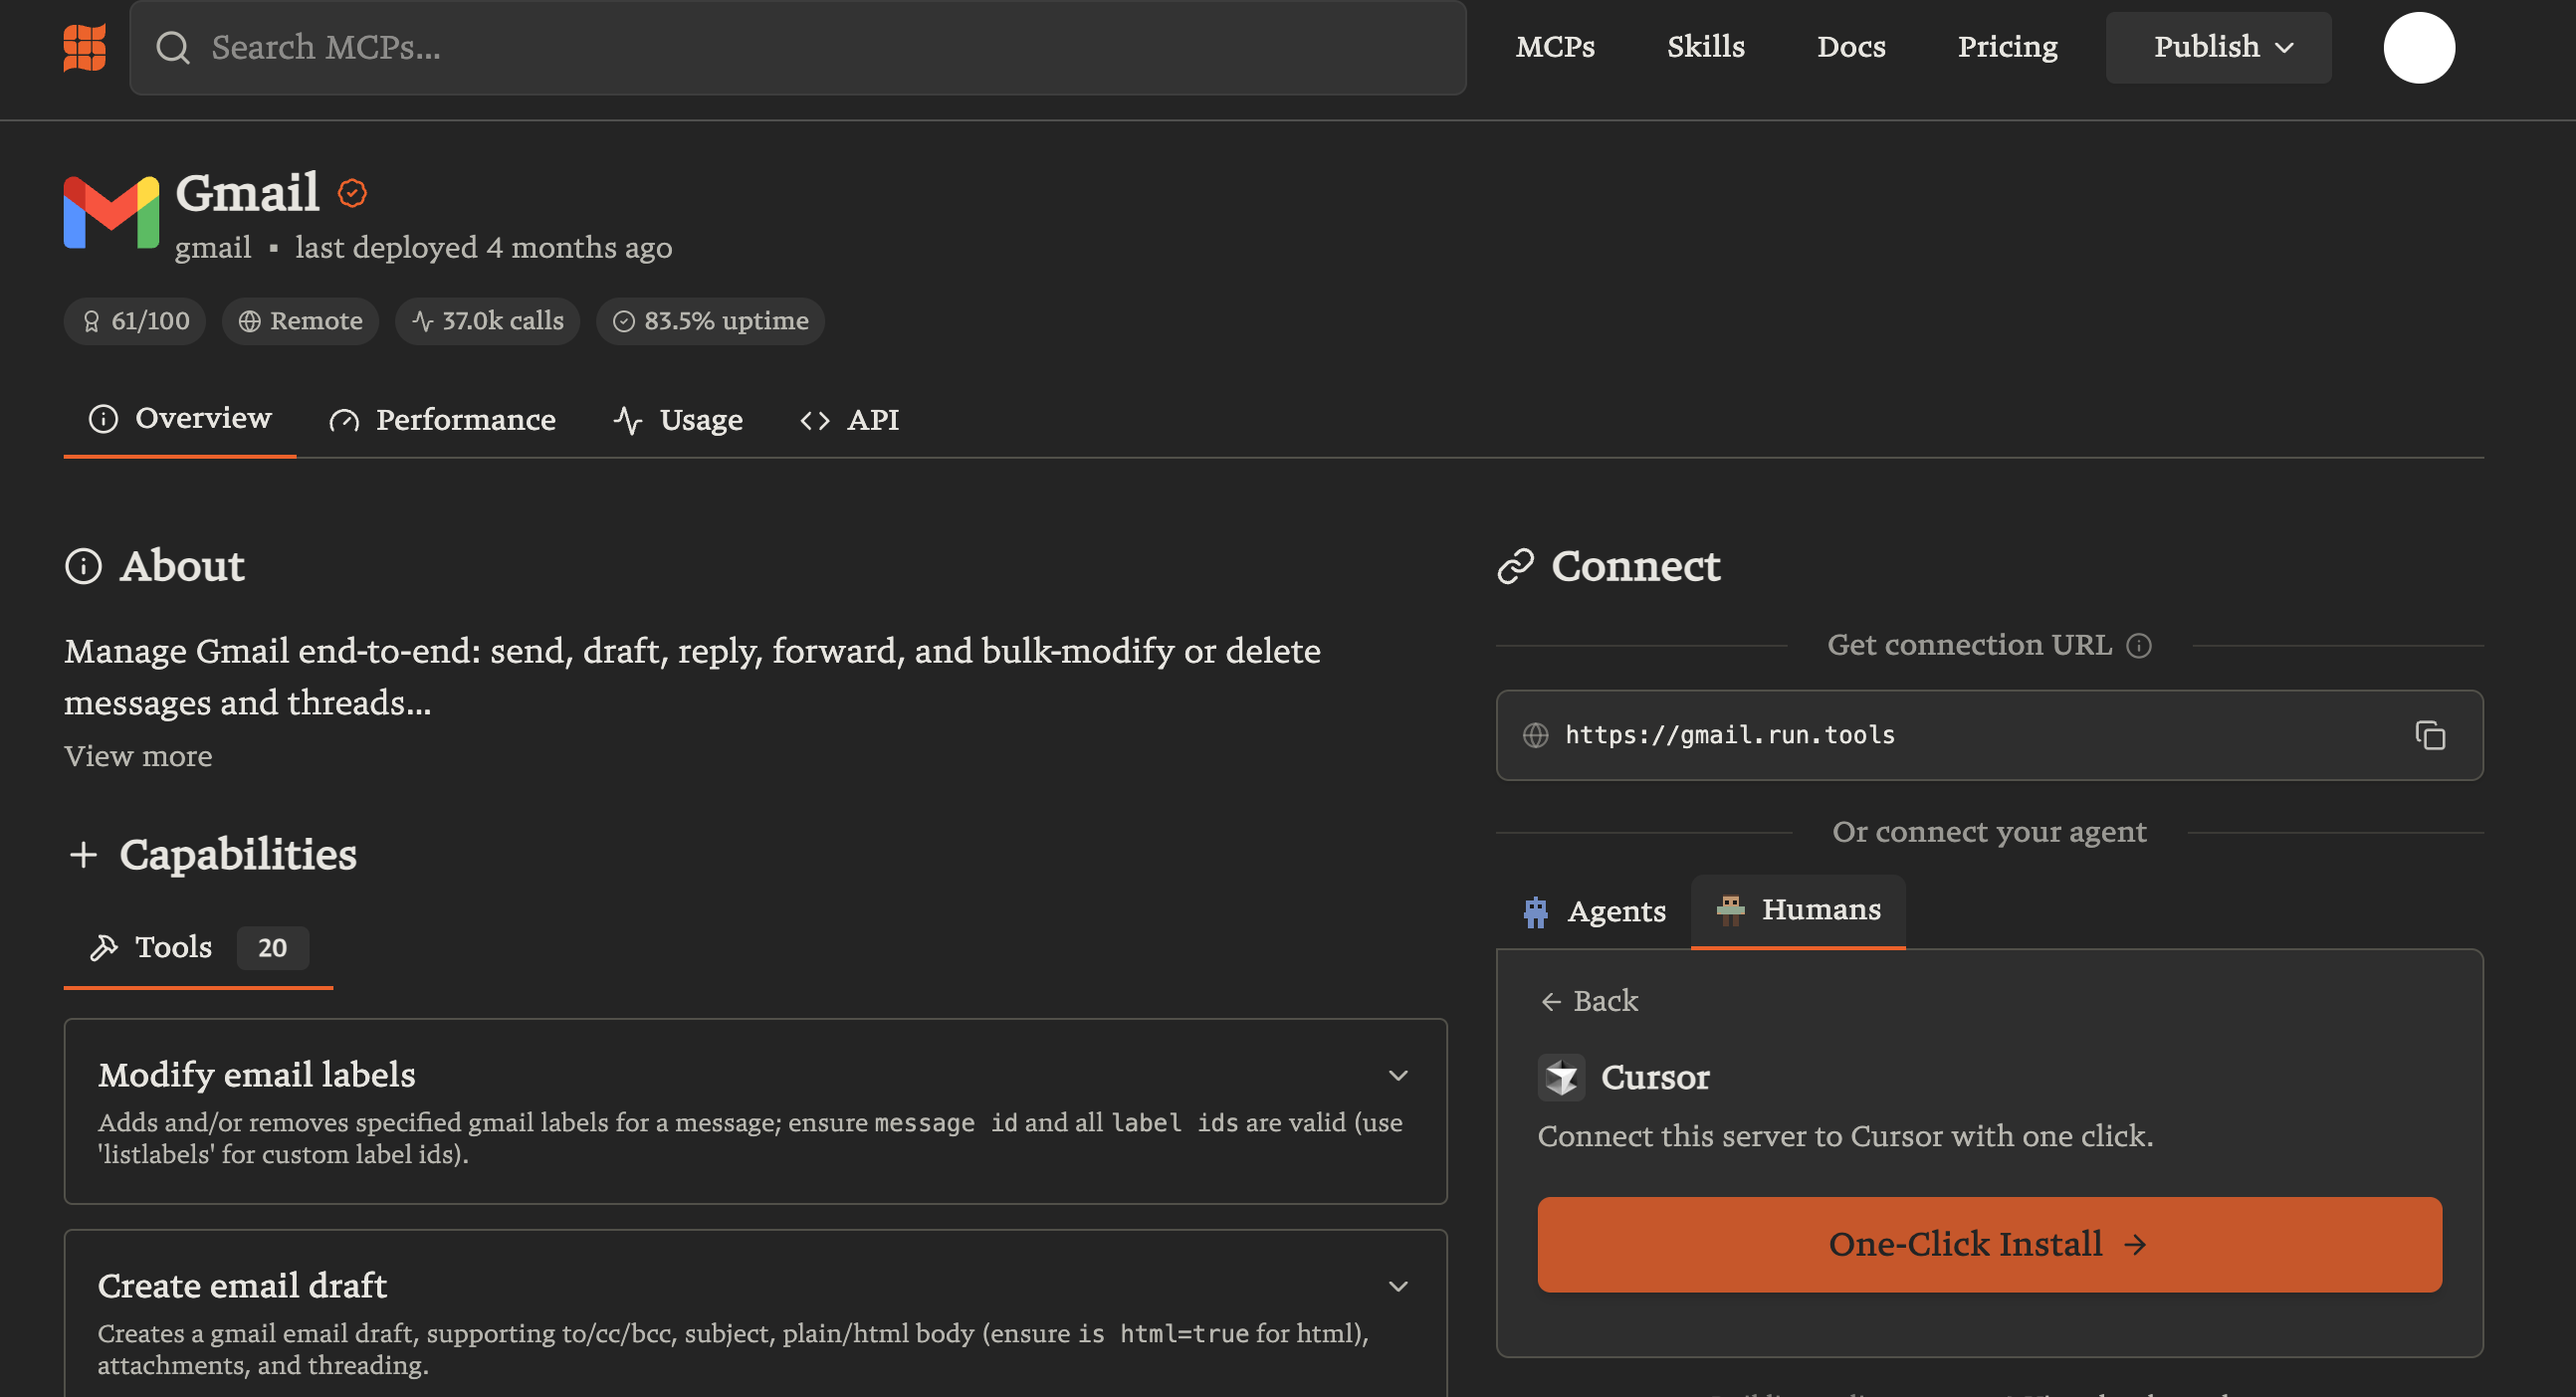

커서에서 설치 확인 및 agent에서 명령
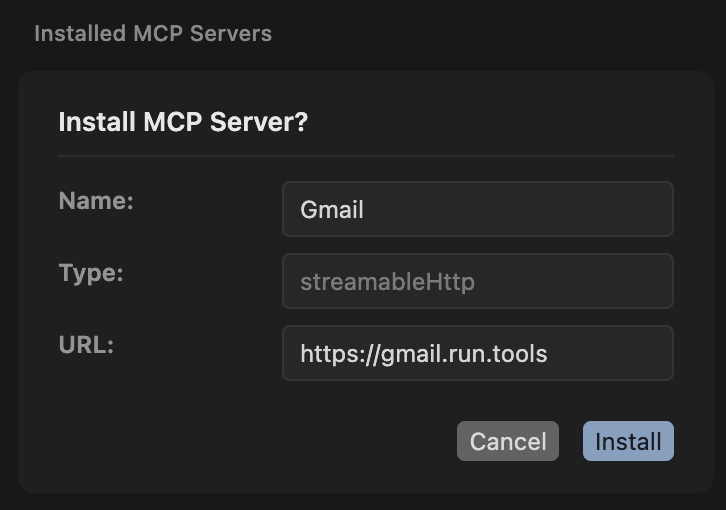

### 설정 파일로 관리하기

GUI 대신 프로젝트 루트에 `.cursor/mcp.json` 파일을 직접 작성할 수도 있다.

```json
{
  "mcpServers": {
    "Gmail": {
      "type": "http",
      "url": "https://gmail.run.tools",
      "headers": {}
    }
  }
}
```

### 여러 서버를 동시에 연결하기

MCP 서버는 여러 개를 동시에 연결할 수 있다. AI가 상황에 맞는 Tool을 알아서 선택해서 호출한다.

## LangGraph Agent에 MCP 연결

Cursor 같은 AI 도구뿐 아니라, 우리가 만드는 LangGraph Agent에도 MCP를 연결할 수 있다.

`langchain-mcp-adapters` 라이브러리가 MCP Tool을 LangChain Tool로 변환해준다.

```bash
uv add langchain-mcp-adapters mcp
```

In [ ]:
from dotenv import load_dotenv

load_dotenv()

True

`MultiServerMCPClient`로 MCP 서버에 연결하고, `get_tools()`로 LangChain Tool을 받아서 Agent에 넣는다.

smitery에서 gmail mcp 최하단의 api guide를 따라간다.

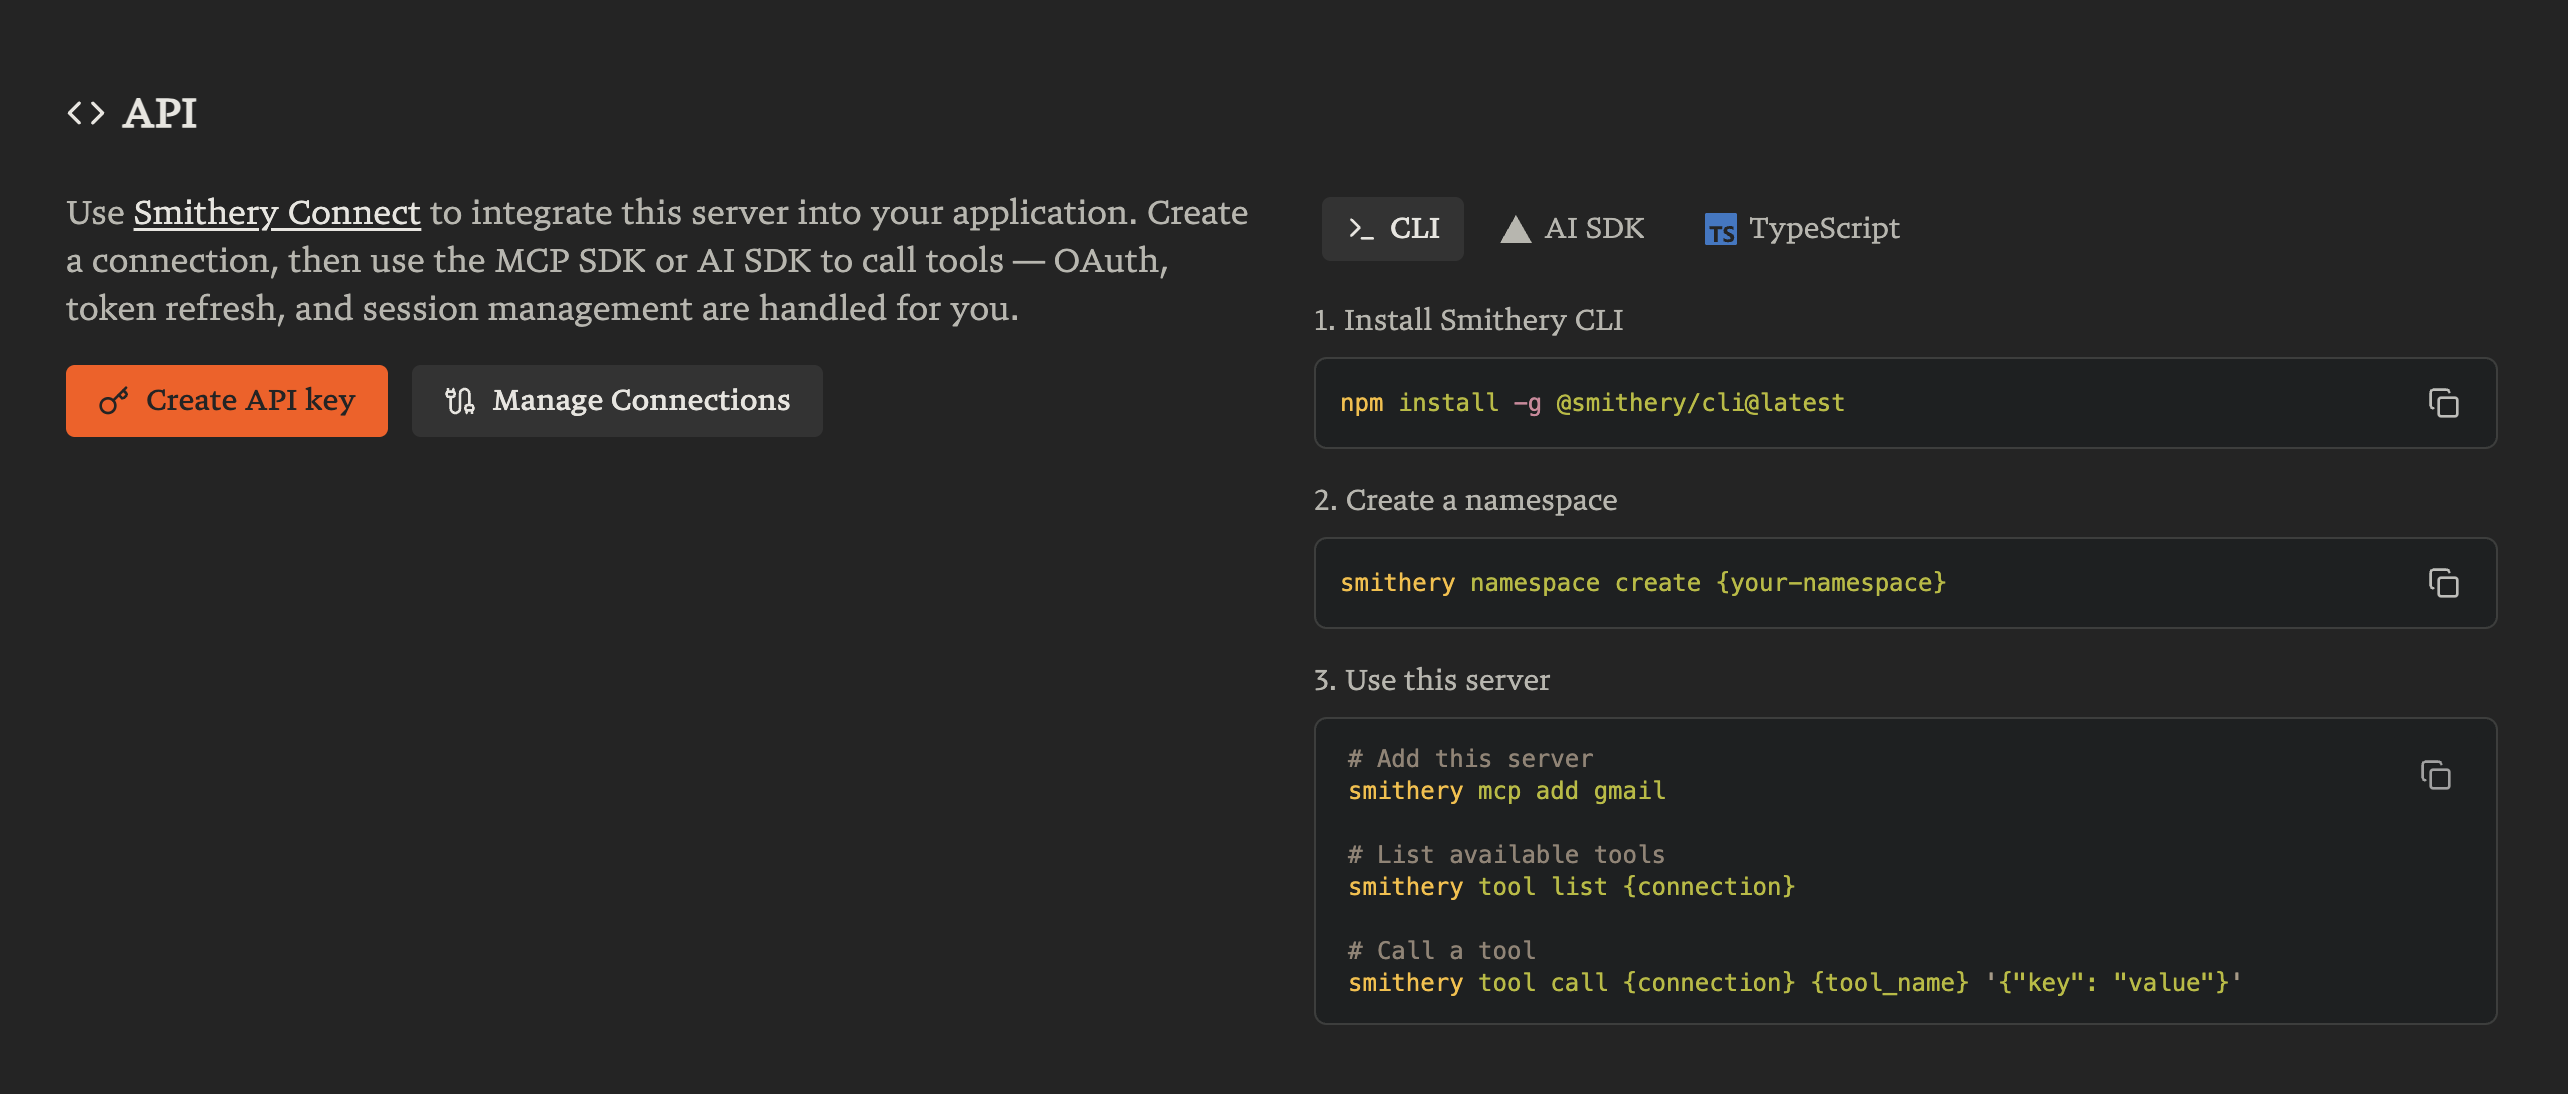

- npm install -g @smithery/cli@latest
- smithery mcp add gmail  
  add 후 나오는 url을 클릭하여 연결한다.

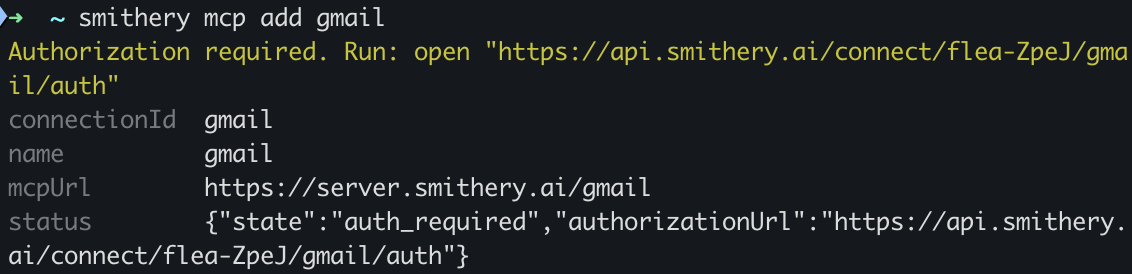


우측 상단의 아이콘 -> my connections에서 연결 확인이 가능하다.
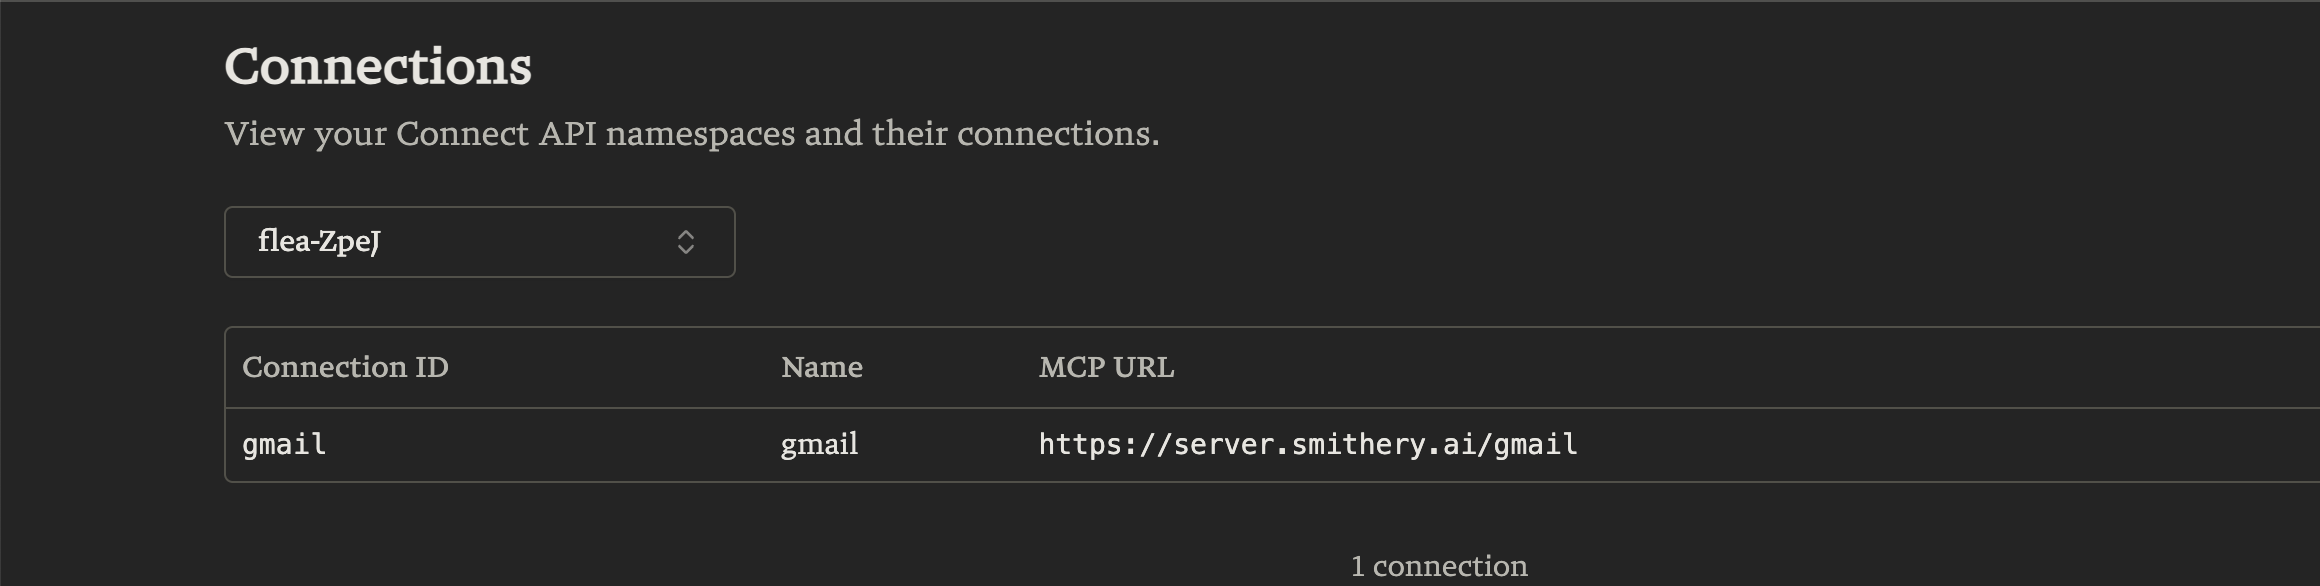


In [38]:
import os
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

client = MultiServerMCPClient(
    {
        "gmail": {
            # "url": "https://api.smithery.ai/connect/{namespace}/{mcp_name}/mcp",
            "url": "https://api.smithery.ai/connect/flea-ZpeJ/gmail/mcp",
            "transport": "streamable_http",
            "headers": {
                "Authorization": f"Bearer {os.environ['SMITHERY_API_KEY']}",
            },
        },
    }
)

tools = await client.get_tools()
print("MCP에서 가져온 Tool 목록:")
for tool in tools:
    print(f"  - {tool.name}: {tool.description}")

MCP에서 가져온 Tool 목록:
  - add_label_to_email: Adds and/or removes specified gmail labels for a message; ensure `message id` and all `label ids` are valid (use 'listlabels' for custom label ids).
  - create_email_draft: Creates a gmail email draft, supporting to/cc/bcc, subject, plain/html body (ensure `is html=true` for html), attachments, and threading.
  - create_label: Creates a new label with a unique name in the specified user's gmail account.
  - delete_draft: Permanently deletes a specific gmail draft using its id; ensure the draft exists and the user has necessary permissions for the given `user id`.
  - delete_message: Permanently deletes a specific email message by its id from a gmail mailbox; for `user id`, use 'me' for the authenticated user or an email address to which the authenticated user has delegated access.
  - fetch_emails: Fetches a list of email messages from a gmail account, supporting filtering, pagination, and optional full content retrieval.
  - fetch_message_by_

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
agent = create_agent(llm, tools)

email = "example@example.com"
result = agent.invoke(
    {"messages": [("user", f"{email}에게 테스트 이메일 보내줘")]}
)
print(result["messages"][-1].content)

## 그런데, 정말 MCP가 필요할까?

위 코드를 `@tool`로 직접 만들면 Gmail API를 직접 연동해야 한다. OAuth 인증, API 호출, 응답 파싱까지 모두 직접 구현해야 하는 것이다.

| | `@tool` 직접 구현 | MCP 연동 |
|---|---|---|
| **코드량** | API 인증 + 호출 + 파싱 직접 구현 | 초기 설정 후 연결 코드만 작성 |
| **실행** | Agent 프로세스 안에서 직접 실행 | 별도 서버와 통신 |
| **유연성** | 자유롭게 커스텀 가능 | MCP 서버가 제공하는 Tool만 사용 |
| **재사용** | 이 프로젝트에서만 | Cursor, Claude Code 등에서도 사용 가능 |

Gmail, Slack, Notion처럼 이미 MCP 서버가 만들어져 있는 서비스는 MCP로 연결하는 것이 간편하다. 반면 우리 서비스에 특화된 로직은 `@tool`로 직접 만드는 것이 낫다.

## 실습: 문서 요약 후 이메일 발송 Agent

주어진 내용을 요약하고, 그 결과를 Gmail MCP로 이메일 보내는 Agent를 만든다.

In [ ]:
document = """
LangGraph는 LangChain 팀이 만든 라이브러리로, LLM 기반 애플리케이션을 그래프 구조로 설계할 수 있게 해준다.
노드(Node)는 각 처리 단계를 나타내고, 엣지(Edge)는 노드 간의 흐름을 정의한다.
StateGraph를 사용하면 상태를 공유하면서 조건 분기, 반복, 병렬 처리 등 복잡한 워크플로우를 구현할 수 있다.
Human-in-the-loop, 체크포인트를 통한 상태 저장, 서브그래프를 통한 모듈화도 지원한다.
ReAct Agent, Plan-and-Execute, Multi-Agent 등 다양한 에이전트 패턴을 구현하는 데 활용된다.
"""

email = "본인이메일@example.com"

result = await agent.ainvoke(
    {"messages": [("user", f"다음 내용을 3줄로 요약해서 {email}로 이메일 보내줘.\n\n{document}")]}
)
print(result["messages"][-1].content)